<a href="https://colab.research.google.com/github/Gabi-galv/Data-science-I/blob/main/ProyectoParteIII_Galv%C3%A1n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Introducción y Objetivo
El objetivo es predecir el nivel de adicción de los jóvenes en una escala de 1 a 10 según diferentes factores como, por ejemplo, el tiempo de uso, la performance académica, la sociabilización, el nivel de estrés, etc. Se utilizará un método de regresión, ya que la variable objetivo es continua.

##2. Configuración del entorno

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
# Configuraciones para visualización
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

##3. Carga del Dataset

In [4]:
url = 'https://raw.githubusercontent.com/Gabi-galv/Data-science-I/main/teen_phone_addiction_dataset.csv'
df = pd.read_csv(url)

##4. Exploración

In [5]:
df.head()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [6]:
print('Información del DataSet')
df.info()

Información del DataSet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control

In [7]:
df.describe()

,ID,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,866.169729,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,1.000000,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,750.750000,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,1500.500000,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,2250.250000,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,3000.000000,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


##4. Hipótesis
- Hipótesis Nula (H0): Las características disponibles no son suficientes para predecir el valor del nivel de adicción con un rendimiento significativamente mejor que un modelo base (ej. predecir siempre el valor medio). Esperaríamos un R² cercano a 0.
- Hipótesis Alternativa (H1): Es posible construir un modelo de regresión (Random Forest Regressor) utilizando las características disponibles que prediga el valor del nivel de adicción con un coeficiente de determinación (R²) significativamente superior a 0 (idealmente > 0.5 o 0.6 para considerarlo útil) y un Error Absoluto Medio (MAE) razonablemente bajo.

##5. Análisis Exploratorio de Datos (EDA)

###5.1 Revisar valores faltantes

In [8]:
missing_values = df.isnull().sum()
print("Valores faltantes por columna:")
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("\nNo hay valores faltantes en el dataset.")

Valores faltantes por columna:
Series([], dtype: int64)

No hay valores faltantes en el dataset.


###5.2. Distribución de la variable objetivo ('Addiction_Level')

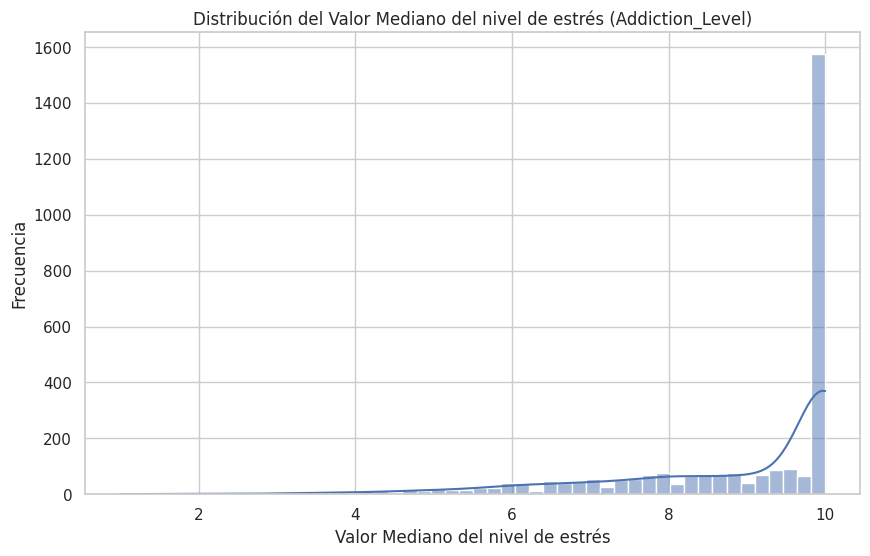

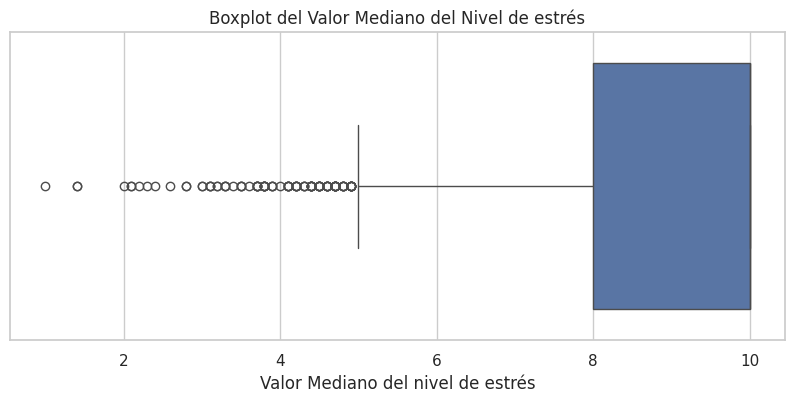

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Addiction_Level'], kde=True, bins=50)
plt.title('Distribución del Valor Mediano del nivel de estrés (Addiction_Level)')
plt.xlabel('Valor Mediano del nivel de estrés')
plt.ylabel('Frecuencia')
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Addiction_Level'])
plt.title('Boxplot del Valor Mediano del Nivel de estrés')
plt.xlabel('Valor Mediano del nivel de estrés')
plt.show()

Observación: Se observa que la variable Addiction_Level presenta valores en gran mayoría cercanos al valor máximo 10. Quizas el modelo tenga problemas para predecir valor bajos.

###5.3. Análisis de variables numéricas (Características)

Características numéricas: ['ID', 'Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Family_Communication', 'Weekend_Usage_Hours']


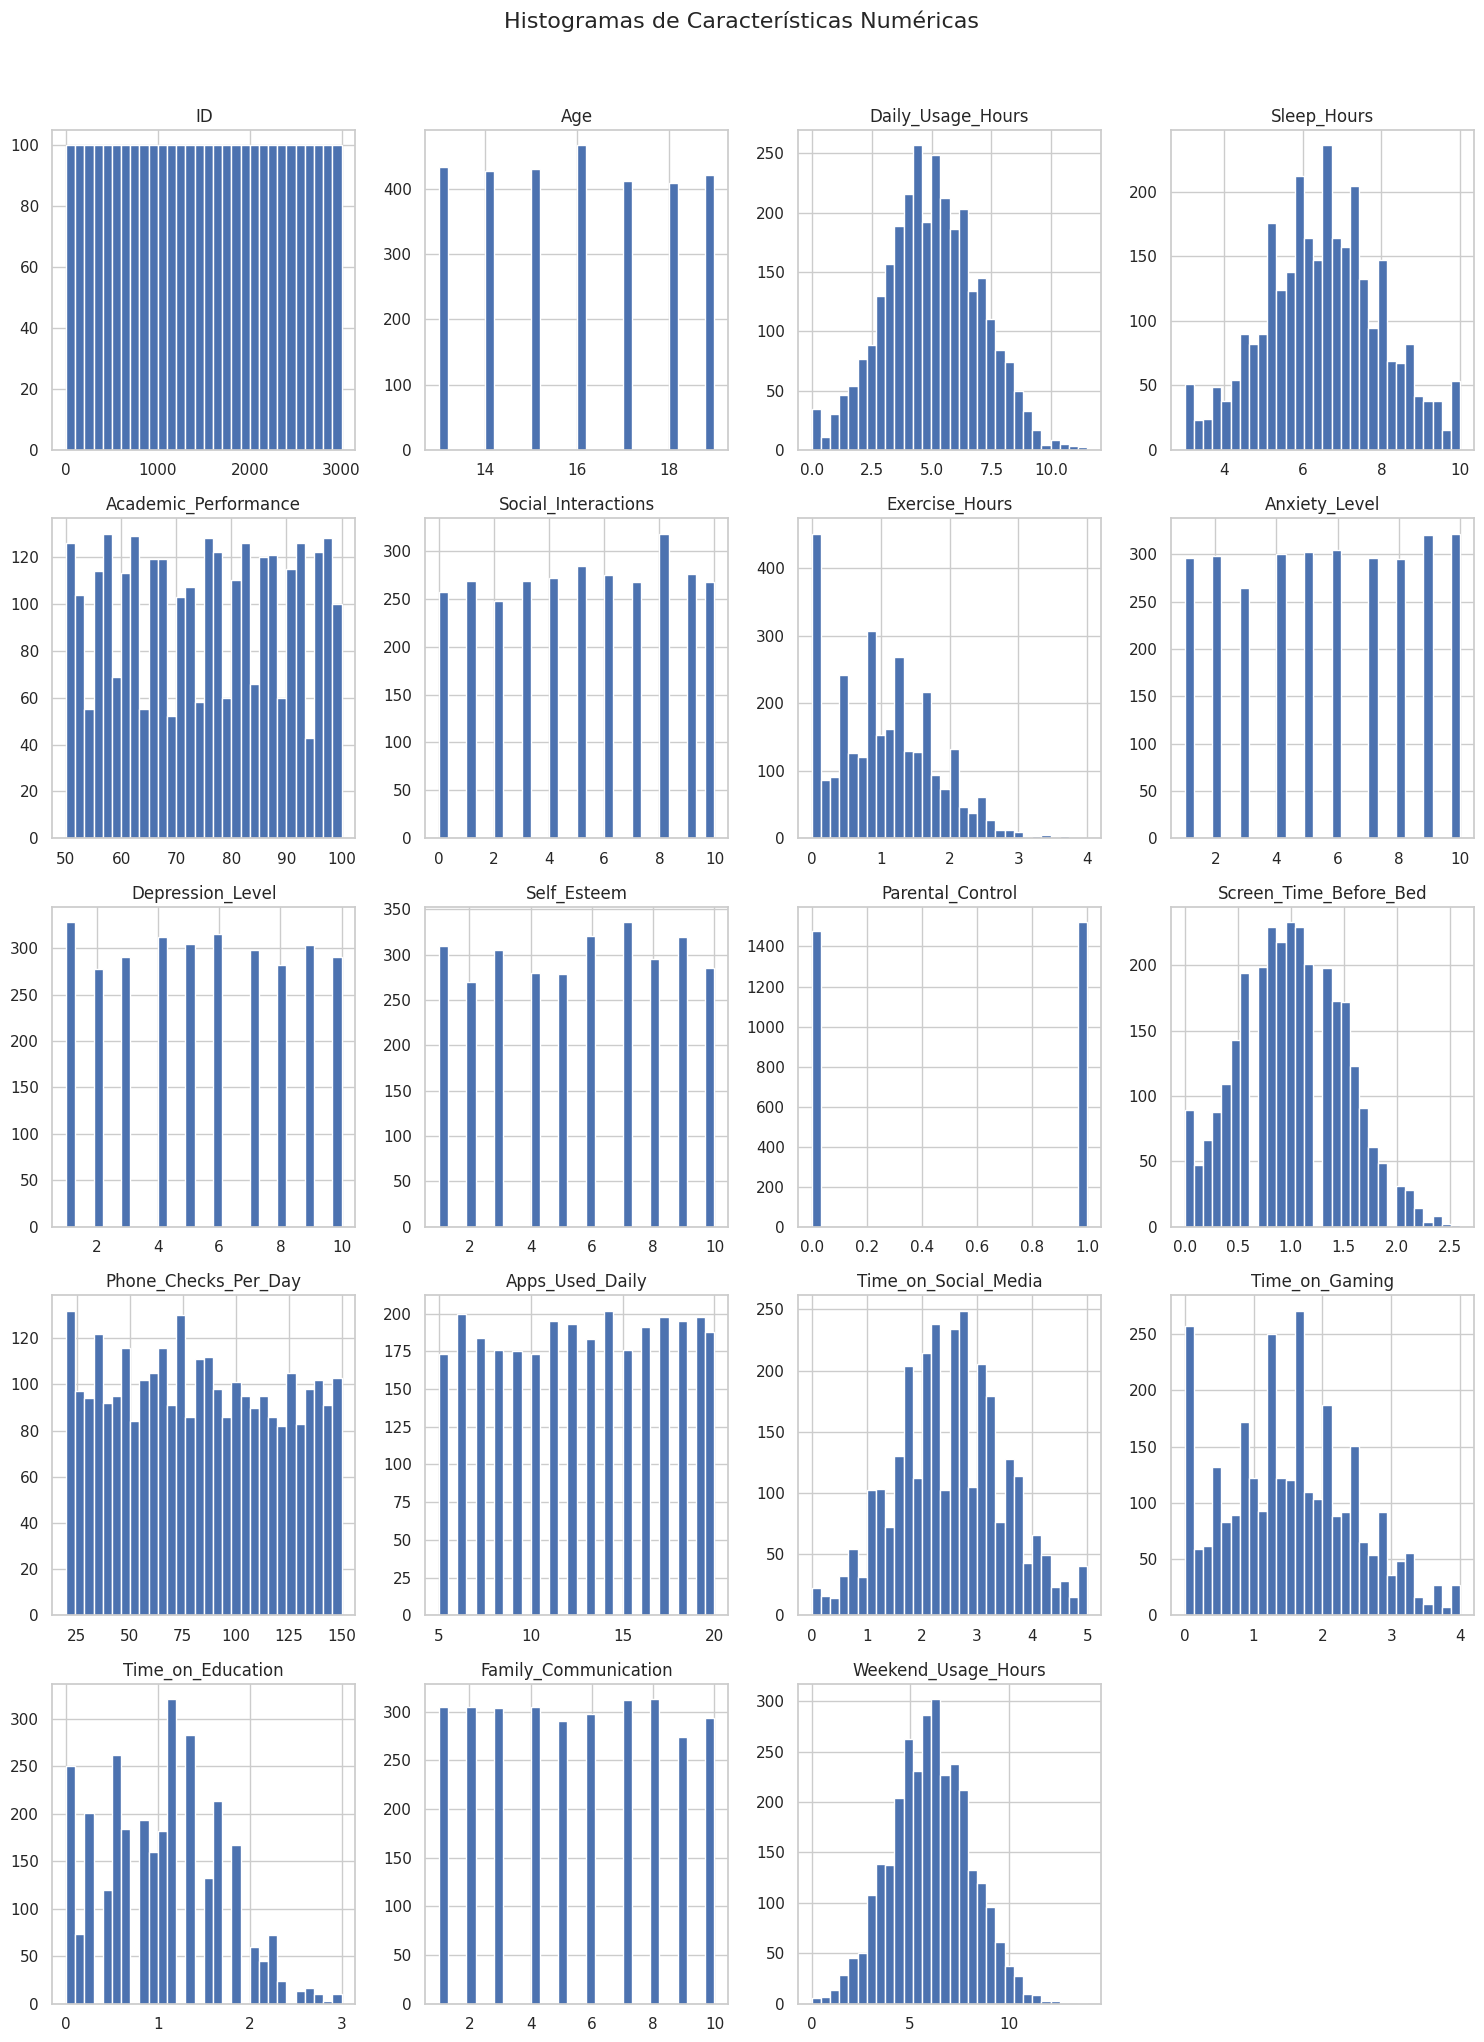

In [10]:
numerical_features = df.select_dtypes(include=np.number).drop('Addiction_Level', axis=1).columns.tolist()
print(f"Características numéricas: {numerical_features}")

# Calculo del n° de filas y columnas necesarias
n_features = len(numerical_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

# Histogramas para todas las características numéricas
df[numerical_features].hist(figsize=(15, n_rows * 4), bins=30, layout=(n_rows, n_cols))
plt.suptitle('Histogramas de Características Numéricas', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

###5.4. Matriz de Correlación

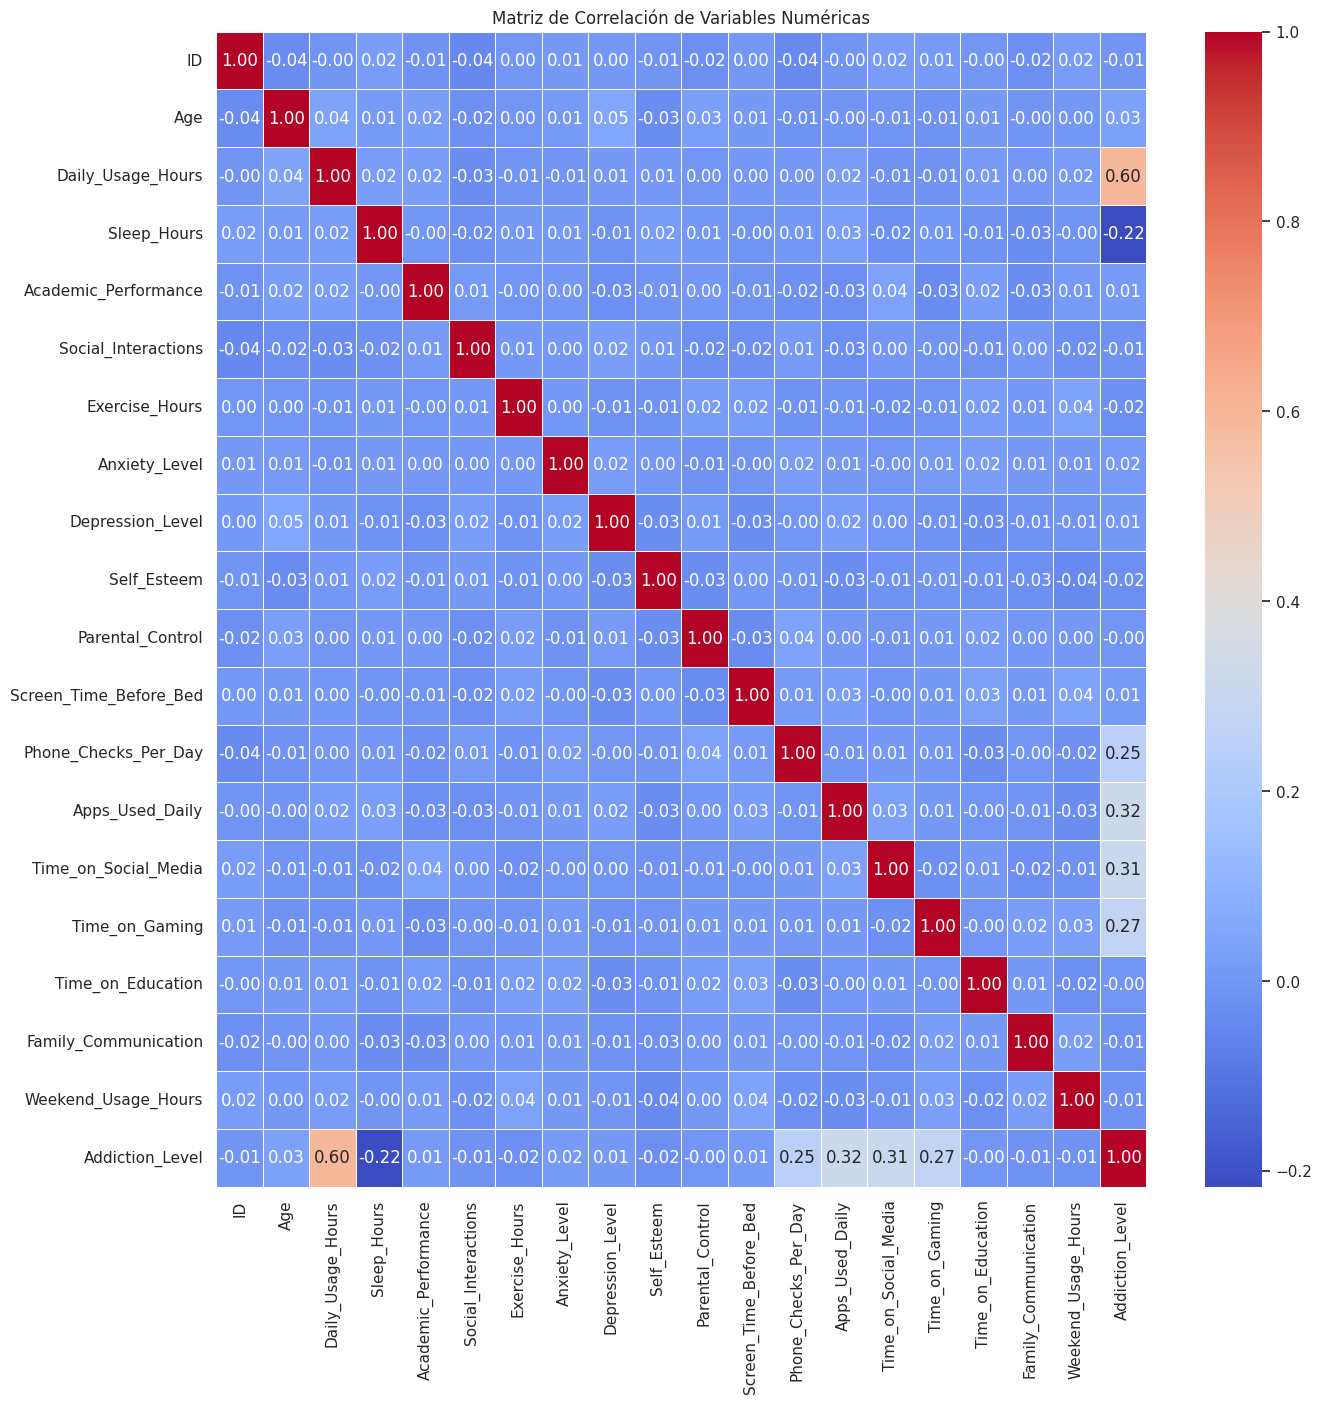


Correlaciones con la variable 'Addiction_Level':
Addiction_Level           1.000000
Daily_Usage_Hours         0.600771
Apps_Used_Daily           0.319287
Time_on_Social_Media      0.306578
Time_on_Gaming            0.273060
Phone_Checks_Per_Day      0.246342
Age                       0.031306
Anxiety_Level             0.016005
Screen_Time_Before_Bed    0.013784
Academic_Performance      0.012264
Depression_Level          0.008491
Time_on_Education        -0.000586
Parental_Control         -0.001016
ID                       -0.007263
Family_Communication     -0.010482
Social_Interactions      -0.010631
Weekend_Usage_Hours      -0.013049
Exercise_Hours           -0.021015
Self_Esteem              -0.022292
Sleep_Hours              -0.216681
Name: Addiction_Level, dtype: float64


In [11]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(15, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

print("\nCorrelaciones con la variable 'Addiction_Level':")
print(correlation_matrix['Addiction_Level'].sort_values(ascending=False))

Observación: Se observa que la Variabble Addiction_Level tiene una alta correlación positiva con la variable Daily_Usage_hours y una cierta correlación negativa con Sleep_Hours. Esto es totalmente lógico y esperable

##7. Preprocesamiento de Datos

In [12]:
# Definir las características (X) y la variable objetivo (y)
X = df.drop('Addiction_Level', axis=1)
y = df['Addiction_Level']

# Identificar características numéricas y categóricas
numerical_features_for_scaling = X.select_dtypes(include=np.number).columns.tolist()
categorical_features_for_encoding = X.select_dtypes(include='object').columns.tolist()

print(f"Características numéricas para escalado: {numerical_features_for_scaling}")
print(f"Características categóricas para codificación: {categorical_features_for_encoding}")

Características numéricas para escalado: ['ID', 'Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Family_Communication', 'Weekend_Usage_Hours']
Características categóricas para codificación: ['Name', 'Gender', 'Location', 'School_Grade', 'Phone_Usage_Purpose']


In [13]:
from sklearn.preprocessing import OneHotEncoder

# Crear el preprocesador usando ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_for_scaling),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_for_encoding)
    ],
    remainder='passthrough'
)

##8. División de Datos (Train/Test Split)

In [15]:
# Dividir los datos ANTES de aplicar el preprocesamiento (específicamente el escalado)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")
print(f"Tamaño del conjunto de entrenamiento (y_train): {y_train.shape}")
print(f"Tamaño del conjunto de prueba (y_test): {y_test.shape}")

Tamaño del conjunto de entrenamiento (X_train): (2400, 24)
Tamaño del conjunto de prueba (X_test): (600, 24)
Tamaño del conjunto de entrenamiento (y_train): (2400,)
Tamaño del conjunto de prueba (y_test): (600,)


##9. Construcción y Entrenamiento del Modelo (Random Forest Regressor)

In [17]:
# Crear el pipeline: incluye el preprocesador y el regresor
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10, min_samples_split=5))
    # n_estimators: número de árboles. 100 es un buen inicio.
    # random_state: para reproducibilidad.
    # n_jobs=-1: usa todos los procesadores disponibles.
    # max_depth: profundidad máxima de los árboles (ayuda a prevenir overfitting).
    # min_samples_split: número mínimo de muestras para dividir un nodo.
])

In [18]:
# Entrenar el pipeline completo (preprocesamiento + modelo)
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['ID', 'Age',
                                                   'Daily_Usage_Hours',
                                                   'Sleep_Hours',
                                                   'Academic_Performance',
                                                   'Social_Interactions',
                                                   'Exercise_Hours',
                                                   'Anxiety_Level',
                                                   'Depression_Level',
                                                   'Self_Esteem',
                                                   'Parental_Control',
                                                   'Screen_Time_Before_Bed',
                                                   'Phone_Checks_Per_Day',
                                                   'Apps_Used_Daily',
                                                   'Time_on_Social_Media',
                                                   'Time_on_Gaming',
                                                   'Time_on_Education',
                                                   'Family_Communication',
                                                   'Weekend_Usage_Hours']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Name', 'Gender', 'Location',
                                                   'School_Grade',
                                                   'Phone_Usage_Purpose'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=10, min_samples_split=5,
                                       n_jobs=-1, random_state=42))])

##10. Evaluación del Modelo

In [19]:
# Realizar predicciones en el conjunto de prueba
y_pred = model_pipeline.predict(X_test)

# Calcular métricas de evaluación
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Absolute Error (MAE): 0.4032
Mean Squared Error (MSE): 0.3598
Root Mean Squared Error (RMSE): 0.5999
R-squared (R²): 0.8572


##10.2. Gráfico de Predicciones vs Valores Reales

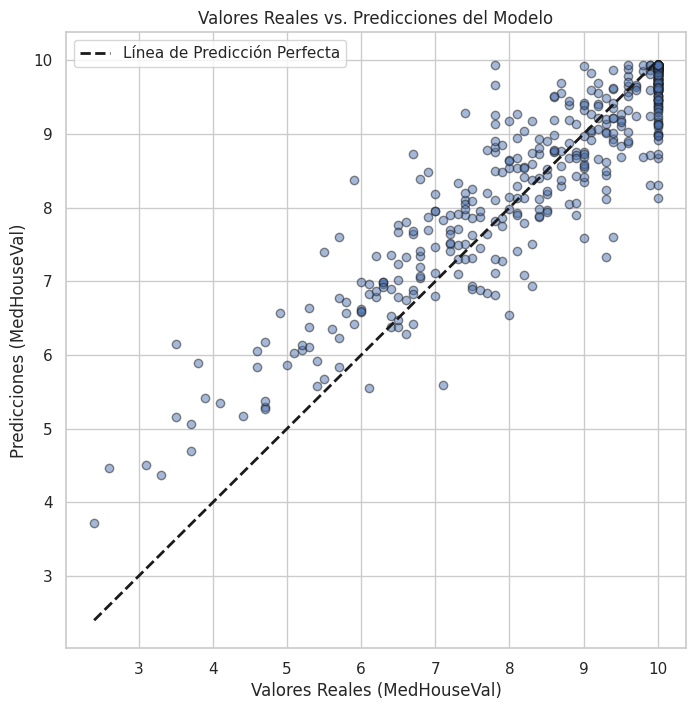

In [20]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Línea de Predicción Perfecta')
plt.xlabel('Valores Reales (MedHouseVal)')
plt.ylabel('Predicciones (MedHouseVal)')
plt.title('Valores Reales vs. Predicciones del Modelo')
plt.legend()
plt.grid(True)
plt.show()

## Análisis de Importancia de Características

Importancia de las características según Random Forest Regressor:
                      Feature  Importance
2      num__Daily_Usage_Hours    0.431672
13       num__Apps_Used_Daily    0.120965
14  num__Time_on_Social_Media    0.110895
15        num__Time_on_Gaming    0.108431
12  num__Phone_Checks_Per_Day    0.085634
3            num__Sleep_Hours    0.057713
18   num__Weekend_Usage_Hours    0.005428
4   num__Academic_Performance    0.005315
6         num__Exercise_Hours    0.005257
0                     num__ID    0.005082


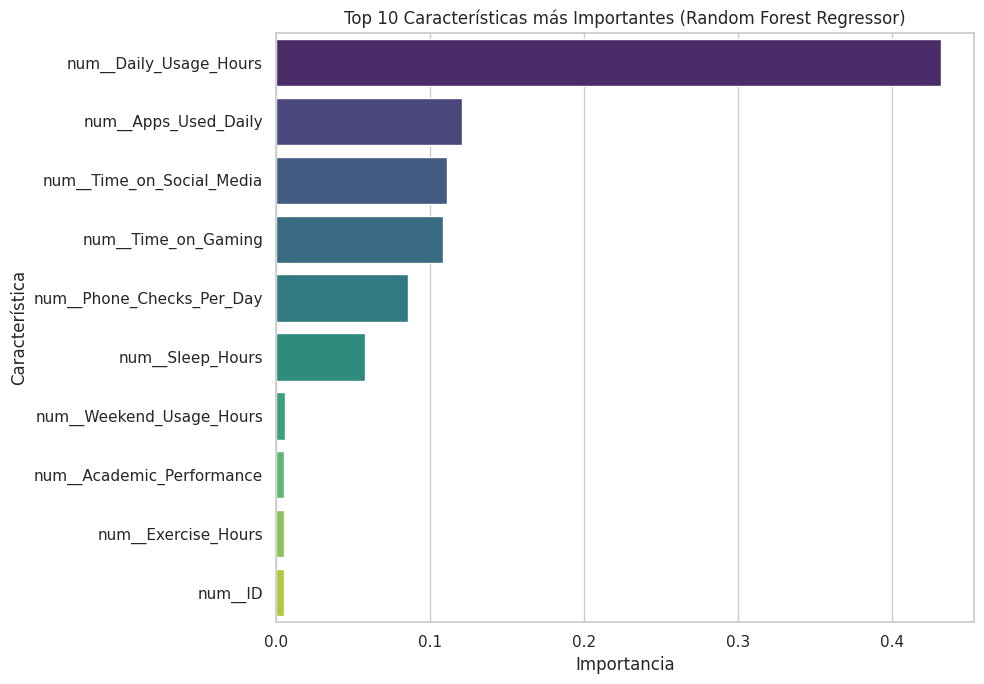

In [21]:
# Acceder al regresor DENTRO del pipeline
regressor_model = model_pipeline.named_steps['regressor']
importances = regressor_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento

fitted_preprocessor = model_pipeline.named_steps['preprocessor']

# Obtener nombres de funciones después del preprocesamiento, incluidas las funciones codificadas one-hot

try:
    feature_names_after_preprocessing = fitted_preprocessor.get_feature_names_out()
except AttributeError:
    # Fallback for older sklearn versions or if get_feature_names_out is not available
    # This is a simplified approach and might not capture all complexities of ColumnTransformer
    numerical_feature_names = numerical_features_for_scaling
    # Get the names of the one-hot encoded features. This is more complex as it depends on the categories found during fit.
    # A common way is to fit the OneHotEncoder separately on X_train and then get feature names.
    # However, since we have the fitted preprocessor, we can try to extract them.
    # This part is a placeholder as getting exact names can be tricky depending on ColumnTransformer structure.
    # For a more robust solution, consider upgrading sklearn or more manual feature name construction.
    print("Warning: get_feature_names_out() not available. Using a simplified approach for feature names.")
    print("Feature names for categorical features after one-hot encoding may not be accurate.")
    # This is a simplified attempt; a production scenario would need more care here.
    categorical_transformer = fitted_preprocessor.named_transformers_['cat']
    if hasattr(categorical_transformer, 'get_feature_names_out'):
         categorical_feature_names = categorical_transformer.get_feature_names_out(categorical_features_for_encoding)
    else:
         # Basic fallback, not ideal
         categorical_feature_names = [f"{col}_{cat}" for col in categorical_features_for_encoding for cat in df[col].unique()]

    feature_names_after_preprocessing = numerical_feature_names + list(categorical_feature_names)


# Crear un DataFrame para visualizar la importancia
feature_importance_df = pd.DataFrame({'Feature': feature_names_after_preprocessing, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Importancia de las características según Random Forest Regressor:")
print(feature_importance_df.head(10)) # Mostrar las 10 más importantes

# Graficar la importancia de las características
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis', hue='Feature', dodge=False)
plt.title('Top 10 Características más Importantes (Random Forest Regressor)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()

##12. Conclusiones

In [24]:
print("Resumen de Resultados del Modelo de Regresión:")
print(f"- Error Absoluto Medio (MAE): {mae:.4f}")
print(f"- Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"- Coeficiente de Determinación (R²): {r2:.4f}")
print("- Las características más importantes fueron: " + ", ".join(feature_importance_df['Feature'].head(3).tolist()) + ".")

Resumen de Resultados del Modelo de Regresión:
- Error Absoluto Medio (MAE): 0.4032
- Raíz del Error Cuadrático Medio (RMSE): 0.5999
- Coeficiente de Determinación (R²): 0.8572
- Las características más importantes fueron: num__Daily_Usage_Hours, num__Apps_Used_Daily, num__Time_on_Social_Media.


##Validación de la Hipótesis:

La hipótesis alternativa (H1) planteaba que era posible predecir el valor mediano de las viviendas con un R² significativamente > 0 (idealmente > 0.5 o 0.6) y un MAE razonablemente bajo.

In [28]:
print(f"Obtuvimos un R² de {r2:.2f} y un MAE de {mae:.2f}")

if r2 > 0.5: # Umbral de ejemplo para R²
    print("RESULTADO: La hipótesis alternativa (H1) es soportada por los resultados. El modelo explica una porción considerable de la varianza y es significativamente mejor que un modelo base.")
    print("Rechazamos la hipótesis nula (H0).")
else:
    print("RESULTADO: La hipótesis alternativa (H1) no es completamente soportada o el modelo tiene un rendimiento bajo (R² <= 0.5).")
    print("Se podría necesitar mejorar el modelo, realizar más ingeniería de características o considerar si las características actuales son suficientes.")

Obtuvimos un R² de 0.86 y un MAE de 0.40
RESULTADO: La hipótesis alternativa (H1) es soportada por los resultados. El modelo explica una porción considerable de la varianza y es significativamente mejor que un modelo base.
Rechazamos la hipótesis nula (H0).
